In [1]:
%pip install seaborn
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import os
from scipy import signal
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, welch
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# DOWNLOAD shared google drive into your local device
# Find the folder in your Library/Finder and click copy or copy path
# paste it into file_path

# Drive:
# file_path = '/content/drive/MyDrive/COGS_189_EEG_Data'

file_path = '/Users/earanda/Downloads/COGS_189_EEG_Data'
 
all_X      = []   # will hold (trials, 8, 225) arrays
all_y      = []   # will hold (trials,) binary label arrays
trial_log  = []   # metadata: sub / ses / run / n_trials / n_errors
 
for sub in sorted(os.listdir(file_path)):
    sub_path = os.path.join(file_path, sub)
    if not (os.path.isdir(sub_path) and sub.startswith('sub-')):
        continue
 
    for ses in sorted(os.listdir(sub_path)):
        ses_path = os.path.join(sub_path, ses)
        if not (os.path.isdir(ses_path) and ses.startswith('ses-')):
            continue
 
        # Collect all run numbers present in this session
        run_nums = set()
        for fname in os.listdir(ses_path):
            if fname.startswith('eeg_trials_run-') and fname.endswith('.npy'):
                run_num = fname.replace('eeg_trials_run-', '').replace('.npy', '')
                run_nums.add(run_num)
 
        for run_num in sorted(run_nums):
            trials_path = os.path.join(ses_path, f'eeg_trials_run-{run_num}.npy')
            labels_path = os.path.join(ses_path, f'labels_run-{run_num}.npy')
 
            # Only load if both files exist
            if not (os.path.exists(trials_path) and os.path.exists(labels_path)):
                print(f"  Skipping {sub}/{ses}/run-{run_num} — missing file")
                continue
 
            X_run = np.load(trials_path, allow_pickle=True)   # (trials, 8, 225)
            y_str = np.load(labels_path, allow_pickle=True)   # (trials,) string
 
            # Handle label shape mismatch (trial_metadata has 50 rows, trials 49)
            # Use the shorter length to keep X and y aligned
            n = min(X_run.shape[0], y_str.shape[0])
            X_run = X_run[:n]
            y_str = y_str[:n]
 
            # Binary encode: error=1, correct=0  (A2 Cell 18 convention)
            y_run = (y_str == 'error').astype(int)
 
            n_err = int(np.sum(y_run))
            n_cor = int(np.sum(y_run == 0))
 
            all_X.append(X_run)
            all_y.append(y_run)
            trial_log.append({
                'sub': sub, 'ses': ses, 'run': run_num,
                'n_trials': n, 'n_errors': n_err, 'n_correct': n_cor
            })
            print(f"  Loaded {sub}/{ses}/run-{run_num}: "
                  f"{n} trials  ({n_cor} correct, {n_err} error)")
 
# concat all the runs

# (total_trials, 8, 225)
X_all = np.concatenate(all_X, axis=0) 
# (total_trials,)
y_all = np.concatenate(all_y, axis=0)  
 
total_trials = X_all.shape[0]
total_errors = int(np.sum(y_all))
total_correct = int(np.sum(y_all == 0))
 
print(f"  Total runs loaded: {len(trial_log)}")
print(f"  Total trials: {total_trials}")
print(f"  Total correct: {total_correct}  ({100*total_correct/total_trials:.1f}%)")
print(f"  Total errors: {total_errors}   ({100*total_errors/total_trials:.1f}%)")
print(f"  X shape: {X_all.shape}")
print(f"  y shape: {y_all.shape}")
 
#parameters for dataset
fs               = 250.0       # Hz
dt               = 1000. / fs  # ms (A1 Cell 39)
sdt              = int(round(dt))
epoch_start_ms   = -500
epoch_end_ms     =  400
pre_start_ms     = -500
pre_end_ms       =   0
baseline_start_ms = -500
baseline_end_ms   = -400
 
pre_s = np.round((pre_start_ms  - epoch_start_ms) / sdt).astype(int)   # 0
pre_e = np.round((pre_end_ms    - epoch_start_ms) / sdt).astype(int)   # 125
bl_s  = np.round((baseline_start_ms - epoch_start_ms) / sdt).astype(int)
bl_e  = np.round((baseline_end_ms   - epoch_start_ms) / sdt).astype(int)
 
channel_names = ['Fz','F3','Cz','C3','C4','Pz','O1','O2']
times_ms = np.linspace(epoch_start_ms, epoch_end_ms, X_all.shape[2])
 
err_idx = np.where(y_all == 1)[0]
cor_idx = np.where(y_all == 0)[0]


  Loaded sub-01/ses-01/run-01: 49 trials  (43 correct, 6 error)
  Loaded sub-01/ses-01/run-02: 50 trials  (44 correct, 6 error)
  Loaded sub-01/ses-01/run-03: 50 trials  (44 correct, 6 error)
  Loaded sub-01/ses-01/run-04: 50 trials  (43 correct, 7 error)
  Loaded sub-02/ses-01/run-01: 50 trials  (48 correct, 2 error)
  Loaded sub-02/ses-01/run-02: 50 trials  (45 correct, 5 error)
  Loaded sub-02/ses-01/run-03: 50 trials  (44 correct, 6 error)
  Loaded sub-02/ses-01/run-04: 50 trials  (46 correct, 4 error)
  Loaded sub-02/ses-02/run-01: 50 trials  (44 correct, 6 error)
  Loaded sub-02/ses-02/run-02: 50 trials  (44 correct, 6 error)
  Loaded sub-02/ses-02/run-03: 50 trials  (46 correct, 4 error)
  Loaded sub-02/ses-02/run-04: 50 trials  (49 correct, 1 error)
  Loaded sub-02/ses-02/run-05: 50 trials  (45 correct, 5 error)
  Loaded sub-02/ses-02/run-06: 50 trials  (45 correct, 5 error)
  Loaded sub-02/ses-02/run-07: 49 trials  (46 correct, 3 error)
  Loaded sub-02/ses-02/run-08: 50 trials

In [4]:
# baseline correction for 3D EEG data
# takes value and subtracts it by the mean of all X values, to normalize it around 0
fs = 250.0       # Hz
dt = 1000. / fs  # ms 
sdt = int(round(dt))
epoch_start_ms = -500
epoch_end_ms = 400
baseline_start_ms = -500
baseline_end_ms = -400

# Convert ms to indices
bl_s  = np.round((baseline_start_ms - epoch_start_ms) / sdt).astype(int)
bl_e  = np.round((baseline_end_ms   - epoch_start_ms) / sdt).astype(int)
 
# Baseline correction
X_bl = X_all.copy()
for i in range(X_bl.shape[0]):              
    for ch in range(X_bl.shape[1]):
        X_bl[i, ch, :] = X_bl[i, ch, :] - np.mean(X_bl[i, ch, bl_s:bl_e])

print(f"Baseline corrected shape: {X_bl.shape}")

Baseline corrected shape: (798, 8, 225)


In [5]:
FS = 250.0   
LOWCUT = 1.0
HIGHCUT = 40.0
BANDPASS_ORDER = 2
NOTCH_FREQ = 60.0
NOTCH_Q = 30.0

def butter_bandpass(lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    return butter(order, [low, high], btype="band", analog=False, output="sos")

def bandpass_filter(data, lowcut, highcut, fs, order=2, axis=-1):
    sos = butter_bandpass(lowcut, highcut, fs, order=order)
    return sosfiltfilt(sos, data, axis=axis)

def notch_filter(data, notch_freq, fs, q=30.0, axis=-1):
    w0 = notch_freq / (fs / 2.0)
    b, a = iirnotch(w0, q)
    return filtfilt(b, a, data, axis=axis)

def average_rereference(data, channel_axis=1):
    return data - np.mean(data, axis=channel_axis, keepdims=True)

def preprocess_eeg_trials(trials, fs=FS, lowcut=LOWCUT, highcut=HIGHCUT,
                          bandpass_order=BANDPASS_ORDER, notch_freq=NOTCH_FREQ, notch_q=NOTCH_Q):
    cleaned = bandpass_filter(trials, lowcut, highcut, fs, order=bandpass_order, axis=2)
    cleaned = notch_filter(cleaned, notch_freq, fs, q=notch_q, axis=2)
    cleaned = average_rereference(cleaned, channel_axis=1)
    return cleaned

# Apply to our baseline-corrected data
X_clean = preprocess_eeg_trials(X_bl)
print(f"Filtered Data Shape: {X_clean.shape}")

Filtered Data Shape: (798, 8, 225)


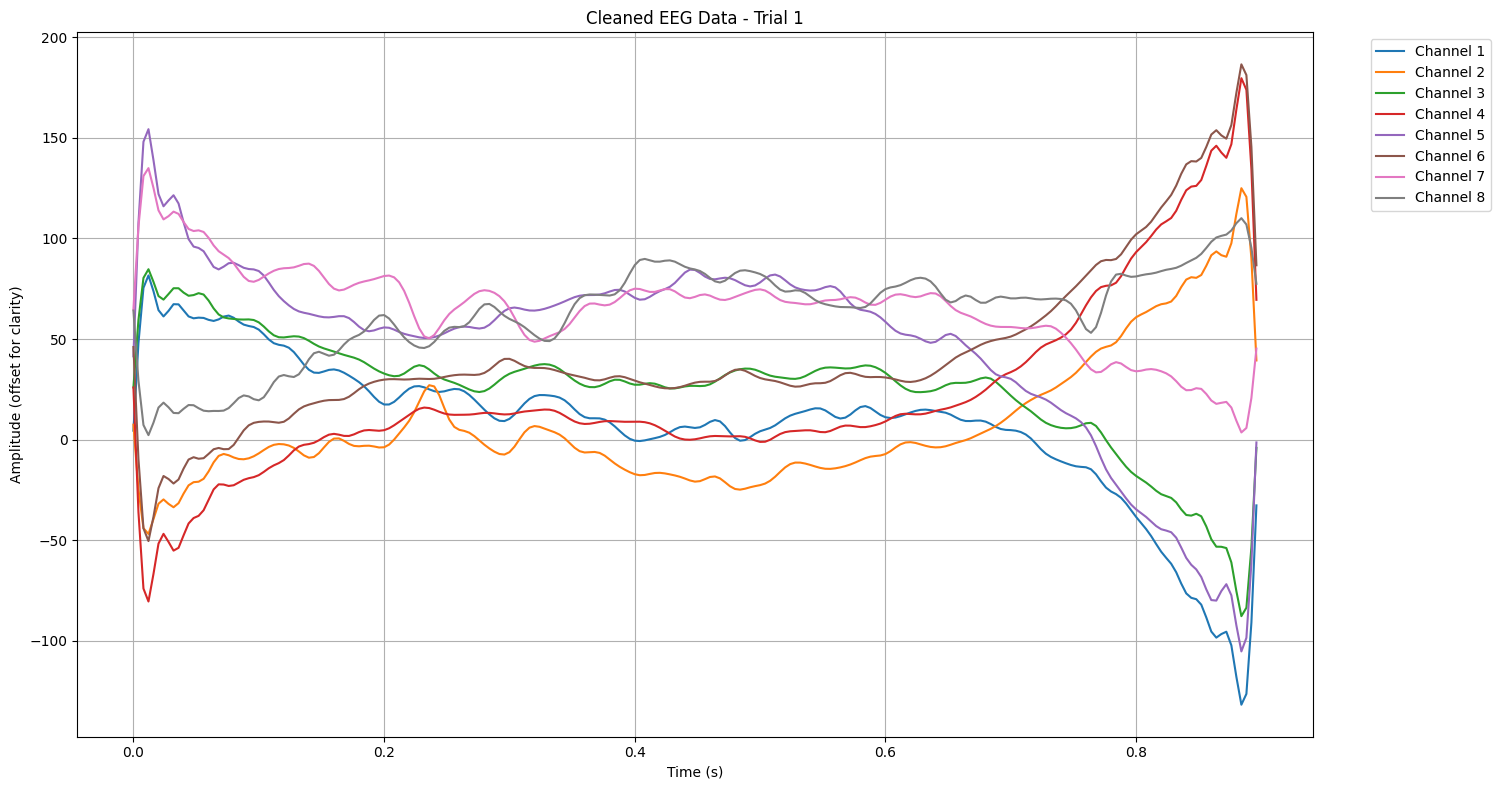

In [6]:
trial_index = 0
single_trial_data = X_clean[trial_index, :, :]

num_channels, num_time_points = single_trial_data.shape
time = np.arange(num_time_points) / FS

plt.figure(figsize=(15, 8))

for i in range(num_channels):
    # Offset each channel by i*10 so they don't overlap
    plt.plot(time, single_trial_data[i, :] + i * 10, label=f'Channel {i+1}') 

plt.title(f'Cleaned EEG Data - Trial {trial_index + 1}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (offset for clarity)')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# Filtering
bands = {
    'theta': (4,  7),
    'alpha': (8, 12),
    'beta' : (13, 30),
}
num_taps = 31   # A2 Cell 14

X_bands = {}
for band_name, (hp, lp) in bands.items():
    b = signal.firwin(numtaps=num_taps, cutoff=[hp, lp],
                      pass_zero='bandpass', fs=fs)   # A2 Cell 14
    a = 1                                             # A2 Cell 14: "for FIR filters, a is always 1"

    X_filt = np.zeros_like(X_bl)
    for i in range(X_bl.shape[0]):          # A2 Cell 18: loop over trials
        for ch in range(X_bl.shape[1]):
            X_filt[i, ch, :] = signal.filtfilt(b, a, X_bl[i, ch, :])  # A2 Cell 18

    X_bands[band_name] = X_filt
    print(f"  [{band_name}] ({hp}–{lp} Hz): {X_filt.shape}")


  [theta] (4–7 Hz): (798, 8, 225)
  [alpha] (8–12 Hz): (798, 8, 225)
  [beta] (13–30 Hz): (798, 8, 225)


In [8]:
CHANNEL_NAMES = ["Fz", "F3", "Cz", "C3", "C4", "Pz", "O1", "O2"]
BANDS = {
    "theta": (4, 7),
    "alpha": (8, 12),
    "beta": (13, 30),
}

def bandpower_1d(x, fs, band, nperseg=None):
    low, high = band
    nperseg = min(len(x), 128) if nperseg is None else nperseg

    freqs, psd = welch(x, fs=fs, nperseg=nperseg)
    mask = (freqs >= low) & (freqs <= high)

    if not np.any(mask): return np.nan

    selected_freqs = freqs[mask]
    selected_psd = psd[mask]

    if selected_freqs.size == 1:
        freq_res = freqs[1] - freqs[0]
        return float(selected_psd[0] * freq_res)

    return float(np.trapezoid(selected_psd, selected_freqs))

def extract_bandpower_features(trials, labels, fs=FS, channel_names=CHANNEL_NAMES, bands=BANDS):
    rows = []
    for trial_idx in range(trials.shape[0]):
        row = {
            "trial": trial_idx,
            "label": "error" if labels[trial_idx] == 1 else "correct"
        }
        trial = trials[trial_idx]

        for ch_idx, ch_name in enumerate(channel_names):
            sig = trial[ch_idx]
            for band_name, band_range in bands.items():
                row[f"{band_name}_{ch_name}"] = bandpower_1d(sig, fs, band_range)

        rows.append(row)

    return pd.DataFrame(rows)

# Generate features directly from memory
feature_table_df = extract_bandpower_features(X_clean, y_all)

display(feature_table_df.head(10))

,trial,label,theta_Fz,alpha_Fz,beta_Fz,theta_F3,alpha_F3,beta_F3,theta_Cz,alpha_Cz,...,beta_C4,theta_Pz,alpha_Pz,beta_Pz,theta_O1,alpha_O1,beta_O1,theta_O2,alpha_O2,beta_O2
0,0,correct,1.321861,3.982295,3.925578,2.267229,7.349736,6.617223,1.861952,2.710826,...,2.583575,1.286651,1.450527,0.703479,1.590990,8.143338,8.366761,7.162659,6.128060,5.191519
1,1,correct,1.734617,1.757569,2.534502,6.112397,1.847448,3.699914,1.097832,0.907777,...,3.778558,1.034208,0.530452,1.025734,4.389171,1.917906,10.746658,4.959751,6.506329,25.598181
2,2,correct,2.824700,1.972858,3.429500,2.118557,4.670550,3.158144,1.444625,0.856548,...,3.963484,2.053247,1.676444,2.542161,4.681856,1.605823,7.680290,4.609148,5.274160,16.539159
3,3,error,6.897308,4.253052,7.120109,3.884163,1.188418,4.766452,0.565722,2.360868,...,4.819920,1.096215,3.606859,1.560819,8.171374,1.248705,10.058953,2.770776,3.685428,12.201979
4,4,correct,2.702984,3.718103,3.425687,2.513052,4.686977,4.916147,2.142155,2.044101,...,4.531310,0.645415,2.461336,1.352353,1.008248,0.961938,5.684733,9.493096,21.416276,12.496606
5,5,correct,1.553619,9.834525,5.513165,2.026588,15.919459,4.830995,2.185345,3.185244,...,5.580925,1.854714,7.248475,1.937224,3.974768,11.406357,4.950427,2.726094,50.600729,24.965741
6,6,correct,13.385953,10.828592,13.781747,5.928327,6.215072,4.224318,0.319995,5.732731,...,1.684278,2.305089,0.917827,0.882894,5.298627,20.348184,10.567571,7.688329,24.660724,26.501730
7,7,error,5.439690,3.208047,6.970203,1.386586,1.976776,3.694780,1.072666,7.344769,...,3.093949,1.435745,3.620669,0.786057,2.188063,4.241243,3.382597,2.429677,30.860121,10.734863
8,8,correct,0.718716,2.192775,3.718931,1.563383,3.861292,8.887599,1.366917,2.111568,...,9.492686,1.019938,0.862091,2.497666,4.777241,6.083944,8.766106,4.293971,15.760727,36.246086
9,9,correct,7.639045,4.734048,8.420313,4.719395,2.703643,4.490602,1.371565,3.762715,...,4.655670,0.652327,1.048674,1.462488,4.889988,6.518577,8.518064,14.169379,2.431210,14.938307


Feature matrix : (798, 24)
Labels         : (798,)
Correct: 721  |  Error: 77  (9.6% errors)
  Fold 1  AUC=0.382    errors in test: 15/160
  Fold 2  AUC=0.559    errors in test: 16/160
  Fold 3  AUC=0.530    errors in test: 16/160
  Fold 4  AUC=0.478    errors in test: 15/159
  Fold 5  AUC=0.609    errors in test: 15/159

── Classification Report (5-Fold CV) ──
              precision    recall  f1-score   support

     Correct       0.91      0.72      0.80       721
       Error       0.11      0.32      0.16        77

    accuracy                           0.68       798
   macro avg       0.51      0.52      0.48       798
weighted avg       0.83      0.68      0.74       798

Mean ROC-AUC : 0.512 ± 0.077
Overall AUC  : 0.520


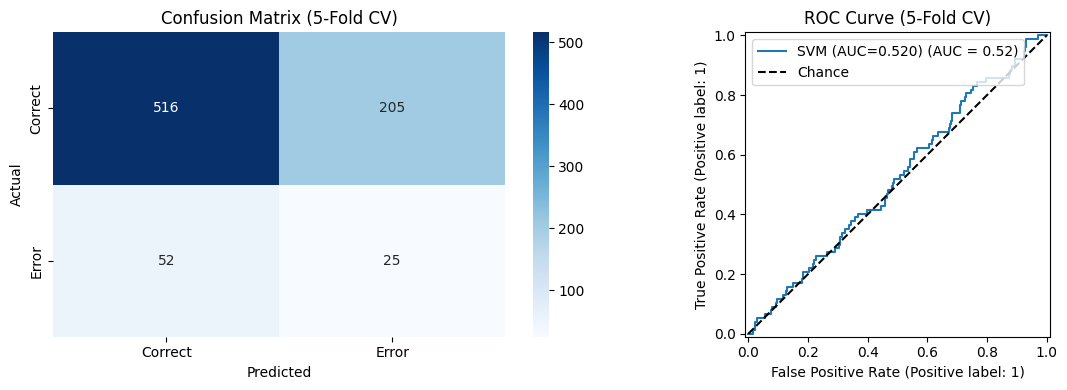

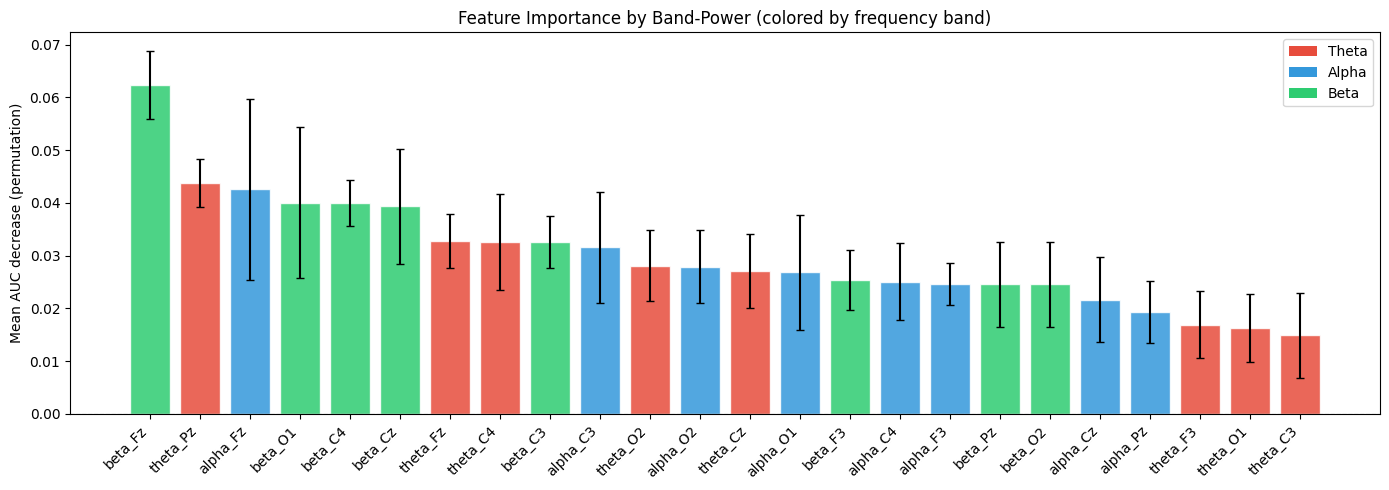

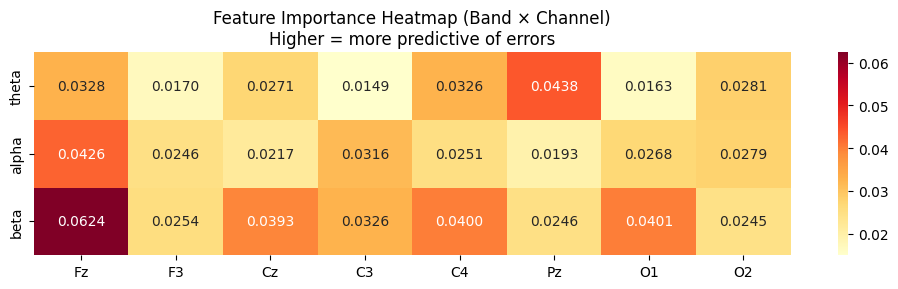


Top 10 most predictive features:
Rank  Feature                Importance        ±Std
────────────────────────────────────────────────────
1     beta_Fz                    0.0624      0.0065
2     theta_Pz                   0.0438      0.0046
3     alpha_Fz                   0.0426      0.0172
4     beta_O1                    0.0401      0.0143
5     beta_C4                    0.0400      0.0044
6     beta_Cz                    0.0393      0.0109
7     theta_Fz                   0.0328      0.0051
8     theta_C4                   0.0326      0.0092
9     beta_C3                    0.0326      0.0050
10    alpha_C3                   0.0316      0.0106


In [ ]:

# 1. PREPARE FEATURE MATRIX FROM YOUR EXISTING feature_table_df

# Drop metadata columns — keep only the 24 band-power features
feature_cols = [c for c in feature_table_df.columns
                if c not in ('trial', 'label')]

X_feat = feature_table_df[feature_cols].values.astype(float)  # (798, 24)
y      = (feature_table_df['label'] == 'error').astype(int).values  # (798,)

print(f"Feature matrix : {X_feat.shape}")
print(f"Labels         : {y.shape}")
print(f"Correct: {(y==0).sum()}  |  Error: {(y==1).sum()}  "
      f"({100*y.mean():.1f}% errors)")

# 2. STRATIFIED K-FOLD SVM
# - Stratified: preserves ~10% error ratio in every fold
# - class_weight='balanced': automatically up-weights the rare error class
# - probability=True: needed for AUC scoring

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

all_true, all_preds, all_probs = [], [], []
fold_aucs = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_feat, y)):
    X_train, X_test = X_feat[train_idx], X_feat[test_idx]
    y_train, y_test = y[train_idx],      y[test_idx]

    # Scale INSIDE the fold — no data leakage
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    svm = SVC(kernel='rbf', class_weight='balanced',
              probability=True, random_state=42)
    svm.fit(X_train, y_train)

    preds = svm.predict(X_test)
    probs = svm.predict_proba(X_test)[:, 1]   # P(error)

    fold_auc = roc_auc_score(y_test, probs)
    fold_aucs.append(fold_auc)

    all_true.extend(y_test)
    all_preds.extend(preds)
    all_probs.extend(probs)

    print(f"  Fold {fold+1}  AUC={fold_auc:.3f}  "
          f"  errors in test: {y_test.sum()}/{len(y_test)}")

# 3. METRICS

print("\n── Classification Report (5-Fold CV) ──")
print(classification_report(all_true, all_preds,
                             target_names=['Correct', 'Error']))
print(f"Mean ROC-AUC : {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")
print(f"Overall AUC  : {roc_auc_score(all_true, all_probs):.3f}")

# 4. CONFUSION MATRIX 

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Correct','Error'],
            yticklabels=['Correct','Error'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (5-Fold CV)')

# ROC Curve
RocCurveDisplay.from_predictions(all_true, all_probs, ax=axes[1],
                                  name=f"SVM (AUC={roc_auc_score(all_true, all_probs):.3f})")
axes[1].plot([0,1],[0,1],'k--', label='Chance')
axes[1].set_title('ROC Curve (5-Fold CV)')
axes[1].legend()
plt.tight_layout()
plt.show()

# 5. FEATURE IMPORTANCE 
# Retrain on ALL data for stable importance estimates

X_all_scaled = StandardScaler().fit_transform(X_feat)
svm_full = SVC(kernel='rbf', class_weight='balanced',
               probability=True, random_state=42)
svm_full.fit(X_all_scaled, y)

result = permutation_importance(
    svm_full, X_all_scaled, y,
    n_repeats=50, random_state=42, scoring='roc_auc'
)

imp_mean = result.importances_mean
imp_std  = result.importances_std
sorted_idx = np.argsort(imp_mean)[::-1]

# 6. IMPORTANCE PLOT — organized by band 
# Color-code by band so you can immediately see theta vs alpha vs beta patterns

band_colors = {
    'theta': '#E74C3C',   # red
    'alpha': '#3498DB',   # blue
    'beta' : '#2ECC71',   # green
}

def get_band(feat_name):
    for b in band_colors:
        if feat_name.startswith(b):
            return b
    return 'other'

sorted_names  = [feature_cols[i] for i in sorted_idx]
sorted_means  = imp_mean[sorted_idx]
sorted_stds   = imp_std[sorted_idx]
colors        = [band_colors[get_band(n)] for n in sorted_names]

plt.figure(figsize=(14, 5))
bars = plt.bar(range(len(sorted_names)), sorted_means,
               yerr=sorted_stds, capsize=3,
               color=colors, alpha=0.85, edgecolor='white')

plt.xticks(range(len(sorted_names)), sorted_names, rotation=45, ha='right')
plt.ylabel('Mean AUC decrease (permutation)')
plt.title('Feature Importance by Band-Power (colored by frequency band)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=b.capitalize())
                   for b, c in band_colors.items()]
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

# 7. HEATMAP — importance as (band × channel) grid 
# This is the most interpretable view for your neuroscience question

CHANNEL_NAMES = ["Fz","F3","Cz","C3","C4","Pz","O1","O2"]
BAND_NAMES    = ["theta","alpha","beta"]

imp_grid = np.zeros((len(BAND_NAMES), len(CHANNEL_NAMES)))
for i, col in enumerate(feature_cols):
    for b_idx, band in enumerate(BAND_NAMES):
        if col.startswith(band):
            ch = col.split('_', 1)[1]
            c_idx = CHANNEL_NAMES.index(ch)
            imp_grid[b_idx, c_idx] = imp_mean[i]

plt.figure(figsize=(10, 3))
sns.heatmap(imp_grid, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=CHANNEL_NAMES, yticklabels=BAND_NAMES)
plt.title('Feature Importance Heatmap (Band × Channel)\nHigher = more predictive of errors')
plt.tight_layout()
plt.show()

# 8. TOP FEATURES SUMMARY 

print("\nTop 10 most predictive features:")
print(f"{'Rank':<5} {'Feature':<20} {'Importance':>12}  {'±Std':>10}")
print("─" * 52)
for rank, idx in enumerate(sorted_idx[:10], 1):
    print(f"{rank:<5} {feature_cols[idx]:<20} "
          f"{imp_mean[idx]:>12.4f}  {imp_std[idx]:>10.4f}")